In [14]:
import numpy as pn
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
#### LOAD THE DATA SET
df = pd.read_csv(r"C:\Users\shash\OneDrive\Desktop\practices\PROJECTS\new projects\IndianElection19TwitterData.csv")
df.head()

,Unnamed: 0,Date,User,Tweet
0,0,2019-05-18 23:50:47+00:00,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,1,2019-05-18 23:20:00+00:00,airnewsalerts,Trinamool Congress Sitting MP Abhishek Banerje...
2,2,2019-05-18 23:00:03+00:00,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
3,3,2019-05-18 22:53:54+00:00,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...
4,4,2019-05-18 22:20:48+00:00,TheNirbhay1,PM Modi creates a new record of being the only...


In [7]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142566 entries, 0 to 142565
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  142566 non-null  int64 
 1   Date        142566 non-null  object
 2   User        142566 non-null  object
 3   Tweet       142566 non-null  object
dtypes: int64(1), object(3)
memory usage: 4.4+ MB


Index(['Unnamed: 0', 'Date', 'User', 'Tweet'], dtype='object')

### Data → Cleaning → Feature Extraction → Model → Evaluation → Prediction

### cleaning

In [11]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Date,User,Tweet
0,2019-05-18 23:50:47+00:00,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,2019-05-18 23:20:00+00:00,airnewsalerts,Trinamool Congress Sitting MP Abhishek Banerje...
2,2019-05-18 23:00:03+00:00,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
3,2019-05-18 22:53:54+00:00,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...
4,2019-05-18 22:20:48+00:00,TheNirbhay1,PM Modi creates a new record of being the only...


### step 1 converting into lower case

In [17]:
Tweet = df["Tweet"].str.lower()
Tweet

0         @anjanaomkashyap i am seeing you as future #bj...
1         trinamool congress sitting mp abhishek banerje...
2         #loksabhaelections2019 \n23rd may 2019 will re...
3         #loksabhaelections2019 \n23rd may 2019 will re...
4         pm modi creates a new record of being the only...
                                ...                        
142561    @mayankgandhi04 @mallesh_2004 early morning #p...
142562    @drkumarvishwas early morning #political move ...
142563    cvoter predicts seat share for upcoming #loksa...
142564    cvoter predicts seat share for upcoming #loksa...
142565    cvoter predicts seat share for upcoming #loksa...
Name: Tweet, Length: 142566, dtype: object

### STEP -2 APPLYING REGER FUNCTION IN THE TEXT DATA TO REMOVE THE UNNESSARY AND MESSED DATA

In [27]:
import re

# Work on the column directly
Tweet = df['Tweet']

# 1. Lowercase
Tweet = Tweet.str.lower()

# 2. Remove emojis / special characters
Tweet = Tweet.str.replace(r'[^\w\s]', '', regex=True)

# 3. Remove numbers
Tweet = Tweet.str.replace(r'\d+', '', regex=True)

# 4. Remove extra whitespaces
Tweet = Tweet.str.replace(r'\s+', ' ', regex=True).str.strip()

# Save back to dataframe
df['clean_text'] = Tweet

print(df['clean_text'].head())

0    anjanaomkashyap i am seeing you as future bjp ...
1    trinamool congress sitting mp abhishek banerje...
2    loksabhaelections rd may will reveal even ecis...
3    loksabhaelections rd may will reveal even ecis...
4    pm modi creates a new record of being the only...
Name: clean_text, dtype: object


## Step 3: Noise Removal

- Remove the following noisy elements using regular expressions (regex):
- URLs
- Email addresses
- Phone numbers
- Mentions (e.g., @username)
- Hashtags (e.g., #NLP)

In [30]:
# Convert to string first
Tweet = df['Tweet'].astype(str)

# Remove phone numbers (10+ digits)
Tweet = Tweet.str.replace(r'\b\d{10,}\b', '', regex=True)

# Remove mentions (@username)
Tweet = Tweet.str.replace(r'@\w+', '', regex=True)

# Remove hashtags (#topic)
Tweet = Tweet.str.replace(r'#\w+', '', regex=True)

# Remove special characters
Tweet = Tweet.str.replace(r'[^a-zA-Z\s]', ' ', regex=True)

# Convert to lowercase
Tweet = Tweet.str.lower()

# Remove extra spaces
Tweet = Tweet.str.replace(r'\s+', ' ', regex=True).str.strip()

# Save back
df['clean_text'] = Tweet

print(df['clean_text'].head())

0    i am seeing you as future spokesperson good lu...
1    trinamool congress sitting mp abhishek banerje...
2    rd may will reveal even ecisveep could not hel...
3    rd may will reveal even could not help modi wi...
4    pm modi creates a new record of being the only...
Name: clean_text, dtype: object


### Step 4: Tokenization
- Tokenize the cleaned text into words
- Store the tokens in a list
- Display the first 20 tokens

In [32]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

tokens = df['clean_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0         [i, am, seeing, you, as, future, spokesperson,...
1         [trinamool, congress, sitting, mp, abhishek, b...
2         [rd, may, will, reveal, even, ecisveep, could,...
3         [rd, may, will, reveal, even, could, not, help...
4         [pm, modi, creates, a, new, record, of, being,...
                                ...                        
142561    [early, morning, move, after, the, detailed, d...
142562    [early, morning, move, after, the, detailed, d...
142563    [cvoter, predicts, seat, share, for, upcoming,...
142564    [cvoter, predicts, seat, share, for, upcoming,...
142565    [cvoter, predicts, seat, share, for, upcoming,...
Name: clean_text, Length: 142566, dtype: object

### Step 5: Stopword Removal
- Remove common stopwords such as:
- the, is, and, of, for, to
- Use NLTK or spaCy stopword list
- Display tokens before and after stopword removal

In [34]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
## before tokens
print(" Tokens BEfore:\n")
print(tokens)

 Tokens BEfore:

0         [i, am, seeing, you, as, future, spokesperson,...
1         [trinamool, congress, sitting, mp, abhishek, b...
2         [rd, may, will, reveal, even, ecisveep, could,...
3         [rd, may, will, reveal, even, could, not, help...
4         [pm, modi, creates, a, new, record, of, being,...
                                ...                        
142561    [early, morning, move, after, the, detailed, d...
142562    [early, morning, move, after, the, detailed, d...
142563    [cvoter, predicts, seat, share, for, upcoming,...
142564    [cvoter, predicts, seat, share, for, upcoming,...
142565    [cvoter, predicts, seat, share, for, upcoming,...
Name: clean_text, Length: 142566, dtype: object


In [38]:
### after the stop words
df['tokens'] = df['clean_text'].str.split()

In [39]:
df['filtered_tokens'] = df['tokens'].apply(
    lambda words: [w for w in words if w not in stop_words]
)

In [40]:
df['filtered_tokens']

0         [seeing, future, spokesperson, good, luck, anj...
1         [trinamool, congress, sitting, mp, abhishek, b...
2         [rd, may, reveal, even, ecisveep, could, help,...
3         [rd, may, reveal, even, could, help, modi, win...
4         [pm, modi, creates, new, record, pm, democrati...
                                ...                        
142561    [early, morning, move, detailed, discussion, a...
142562    [early, morning, move, detailed, discussion, a...
142563            [cvoter, predicts, seat, share, upcoming]
142564            [cvoter, predicts, seat, share, upcoming]
142565            [cvoter, predicts, seat, share, upcoming]
Name: filtered_tokens, Length: 142566, dtype: object

### Step 6: Text Normalization Techniques
- Apply both techniques below and compare them:
- Stemming
- Use PorterStemmer
- Convert words like:

In [ ]:
## reduce words to their root form (may not be a valid word).

In [43]:
stemmer = PorterStemmer()

df['stemmed_text'] = df['clean_text'].apply(
    lambda text: " ".join([stemmer.stem(word) for word in text.split()])
)

print(df[['clean_text', 'stemmed_text']].head())

                                          clean_text  \
0  i am seeing you as future spokesperson good lu...   
1  trinamool congress sitting mp abhishek banerje...   
2  rd may will reveal even ecisveep could not hel...   
3  rd may will reveal even could not help modi wi...   
4  pm modi creates a new record of being the only...   

                                        stemmed_text  
0  i am see you as futur spokesperson good luck a...  
1  trinamool congress sit mp abhishek banerje sen...  
2  rd may will reveal even ecisveep could not hel...  
3  rd may will reveal even could not help modi wi...  
4  pm modi creat a new record of be the onli pm o...  


### Lemmatization
- Use WordNetLemmatizer or spaCy
- Convert words like:
- better → good
- running → run

In [44]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['lemmatized_text'] = df['clean_text'].apply(
    lambda text: " ".join([lemmatizer.lemmatize(word) for word in text.split()])
)

print(df[['clean_text', 'lemmatized_text']].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shash\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                          clean_text  \
0  i am seeing you as future spokesperson good lu...   
1  trinamool congress sitting mp abhishek banerje...   
2  rd may will reveal even ecisveep could not hel...   
3  rd may will reveal even could not help modi wi...   
4  pm modi creates a new record of being the only...   

                                     lemmatized_text  
0  i am seeing you a future spokesperson good luc...  
1  trinamool congress sitting mp abhishek banerje...  
2  rd may will reveal even ecisveep could not hel...  
3  rd may will reveal even could not help modi wi...  
4  pm modi creates a new record of being the only...  


### Step 7: Reconstruct Clean Text
- Combine the final tokens back into sentences
- Create a final cleaned text
- Display:
- Original text
- Final preprocessed text

In [53]:
### Before and After Lemmaized

df['final_text'] = df['clean_text']   # OR use lemmatized_text

print(df[['Tweet', 'final_text']].head())

                                               Tweet  \
0  @anjanaomkashyap i am seeing you as future #bj...   
1  trinamool congress sitting mp abhishek banerje...   
2  #loksabhaelections2019 \n23rd may 2019 will re...   
3  #loksabhaelections2019 \n23rd may 2019 will re...   
4  pm modi creates a new record of being the only...   

                                          final_text  
0  i am seeing you as future spokesperson good lu...  
1  trinamool congress sitting mp abhishek banerje...  
2  rd may will reveal even ecisveep could not hel...  
3  rd may will reveal even could not help modi wi...  
4  pm modi creates a new record of being the only...  


In [54]:
df['final_text']

0         i am seeing you as future spokesperson good lu...
1         trinamool congress sitting mp abhishek banerje...
2         rd may will reveal even ecisveep could not hel...
3         rd may will reveal even could not help modi wi...
4         pm modi creates a new record of being the only...
                                ...                        
142561    early morning move after the detailed discussi...
142562    early morning move after the detailed discussi...
142563           cvoter predicts seat share for upcoming in
142564       cvoter predicts seat share for upcoming in and
142565           cvoter predicts seat share for upcoming in
Name: final_text, Length: 142566, dtype: object

### step 8 Convert Text → Numbers (TF-IDF)

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['final_text'])
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2550692 stored elements and shape (142566, 5000)>

In [61]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['final_text'].apply(get_sentiment)

y = df['sentiment']

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shash\AppData\Roaming\nltk_data...


### step 9 Train-Test Split

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### step 10 Train Model

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\shash\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### step 11 Evaluate Model

In [64]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8723083397629234
              precision    recall  f1-score   support

    negative       0.87      0.81      0.83      8600
     neutral       0.84      0.89      0.86      6383
    positive       0.89      0.91      0.90     13531

    accuracy                           0.87     28514
   macro avg       0.87      0.87      0.87     28514
weighted avg       0.87      0.87      0.87     28514



### step 12 Test With Your Own Input

In [66]:
sample = ["Modi is doing a great job"]
sample_vec = vectorizer.transform(sample)

print(model.predict(sample_vec))

['positive']


In [68]:
df['sentiment']

0         positive
1          neutral
2         negative
3         negative
4         positive
            ...   
142561    positive
142562    positive
142563    positive
142564    positive
142565    positive
Name: sentiment, Length: 142566, dtype: object

#### Sentiment Analyzer
### STEP 1: Make Sure You Have Sentiment Column

In [69]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['final_text'].apply(get_sentiment)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\shash\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### STEP 2: Overall Sentiment Distribution

In [70]:
df['sentiment'].value_counts()

sentiment
positive    67564
negative    43014
neutral     31988
Name: count, dtype: int64

### STEP 3: Visualize Sentiment

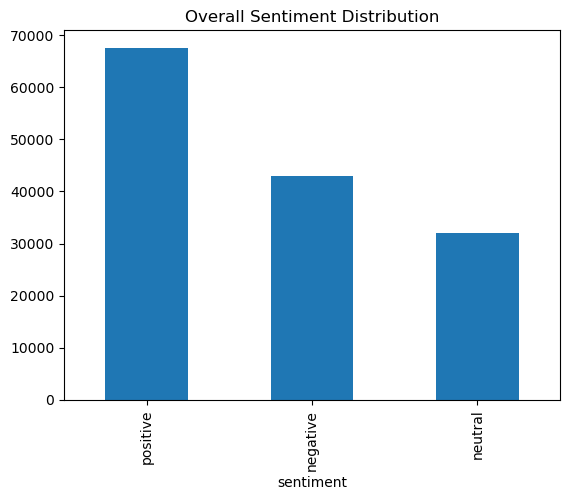

In [71]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Overall Sentiment Distribution")
plt.show()

### STEP 4: Sentiment by User

In [72]:
user_sentiment = df.groupby(['User', 'sentiment']).size().unstack(fill_value=0)

print(user_sentiment.head())

sentiment     negative  neutral  positive
User                                     
0007_CJ              0        1         0
001_chandan          2        0         0
001amitsingh         0        2         0
001ankitG            0        0         1
002_akash            0        0         1


### STEP 5: Who Has Most Positive Tweets

In [73]:
top_positive = user_sentiment.sort_values(by='positive', ascending=False)

print(top_positive.head(10))

sentiment        negative  neutral  positive
User                                        
kumardurgesh262         5        0       605
vikram140gulati       448      223       481
nallaganesh           128       87       267
pkm1999                69       65       223
ramchandani2000       155      700       218
umakantsingh_IN       231       56       207
LaksshyaAdvani         88      139       190
iamTapanPandya         49       81       165
SandipGhose            94       51       154
VandanaMegastar        32       29       151


### STEP 6: Percentage Analysis

In [74]:
user_sentiment['total'] = user_sentiment.sum(axis=1)
user_sentiment['positive_ratio'] = user_sentiment['positive'] / user_sentiment['total']

top_users = user_sentiment.sort_values(by='positive_ratio', ascending=False)

print(top_users.head(10))

sentiment      negative  neutral  positive  total  positive_ratio
User                                                             
004Pruth              0        0         1      1             1.0
007Bhas               0        0         1      1             1.0
zuban_daraz           0        0         1      1             1.0
zuban_kesarii         0        0         2      2             1.0
zuhail786             0        0         1      1             1.0
zukham                0        0         1      1             1.0
zupulut               0        0         1      1             1.0
zytriah9801           0        0         2      2             1.0
zzzsumit              0        0         1      1             1.0
002_akash             0        0         1      1             1.0


### STEP 7: Sentiment Over Time

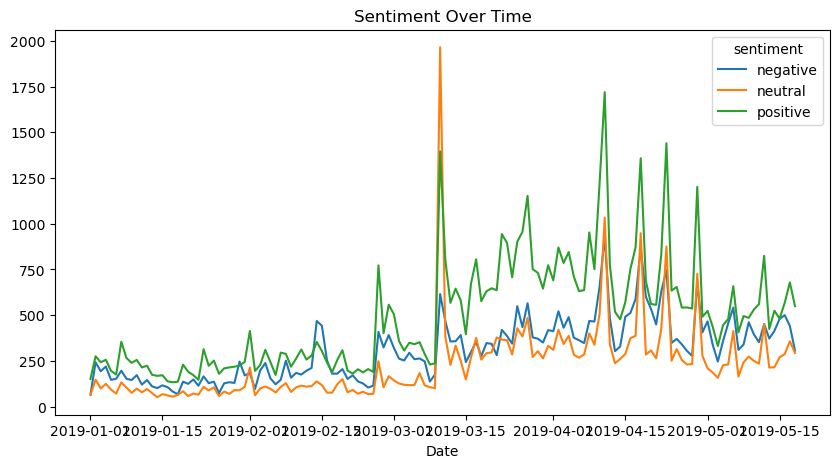

In [75]:
df['Date'] = pd.to_datetime(df['Date'])

time_sentiment = df.groupby([df['Date'].dt.date, 'sentiment']).size().unstack()

time_sentiment.plot(figsize=(10,5))
plt.title("Sentiment Over Time")
plt.show()

### STEP 8: Most Common Positive Words

In [76]:
from collections import Counter

positive_words = " ".join(df[df['sentiment']=='positive']['final_text']).split()

common_words = Counter(positive_words).most_common(10)
print(common_words)

[('the', 51438), ('to', 49826), ('of', 38073), ('in', 34864), ('and', 30826), ('is', 30364), ('for', 27804), ('a', 25155), ('you', 18829), ('will', 15373)]


### Top Positive Users

In [78]:
user_sentiment = df.groupby(['User', 'sentiment']).size().unstack(fill_value=0)

top_positive = user_sentiment.sort_values(by='positive', ascending=False).head(10)

print(top_positive)

sentiment        negative  neutral  positive
User                                        
kumardurgesh262         5        0       605
vikram140gulati       448      223       481
nallaganesh           128       87       267
pkm1999                69       65       223
ramchandani2000       155      700       218
umakantsingh_IN       231       56       207
LaksshyaAdvani         88      139       190
iamTapanPandya         49       81       165
SandipGhose            94       51       154
VandanaMegastar        32       29       151


### Sample Predictions

In [79]:
df[['Tweet', 'sentiment']].head(10)

,Tweet,sentiment
0,@anjanaomkashyap i am seeing you as future #bj...,positive
1,trinamool congress sitting mp abhishek banerje...,neutral
2,#loksabhaelections2019 \n23rd may 2019 will re...,negative
3,#loksabhaelections2019 \n23rd may 2019 will re...,negative
4,pm modi creates a new record of being the only...,positive
5,my somewhat biased exit poll for india electio...,negative
6,@rupasubramanya even assuming statistical erro...,positive
7,@abhijitmajumder small correction. nobody gets...,neutral
8,we still fucking dancing 🕺🏼 ♏️ #inc,neutral
9,@abhijitmajumder appointment of successor! \n\...,positive


In [81]:
df[['Tweet', 'final_text', 'sentiment']].head(5)

,Tweet,final_text,sentiment
0,@anjanaomkashyap i am seeing you as future #bj...,i am seeing you as future spokesperson good lu...,positive
1,trinamool congress sitting mp abhishek banerje...,trinamool congress sitting mp abhishek banerje...,neutral
2,#loksabhaelections2019 \n23rd may 2019 will re...,rd may will reveal even ecisveep could not hel...,negative
3,#loksabhaelections2019 \n23rd may 2019 will re...,rd may will reveal even could not help modi wi...,negative
4,pm modi creates a new record of being the only...,pm modi creates a new record of being the only...,positive


In [82]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
positive    47.391384
negative    30.171289
neutral     22.437327
Name: proportion, dtype: float64